In [1]:
pip install imblearn

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.preprocessing import OneHotEncoder, TargetEncoder
from sklearn.model_selection import KFold
from sklearn.impute import SimpleImputer

from imblearn.over_sampling import RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler

In [3]:
data = pd.read_csv('data/training_v2.csv')
pd.set_option('display.max_columns', None)
data.head(5)

,encounter_id,patient_id,hospital_id,hospital_death,age,bmi,elective_surgery,ethnicity,gender,height,hospital_admit_source,icu_admit_source,icu_id,icu_stay_type,icu_type,pre_icu_los_days,readmission_status,weight,albumin_apache,apache_2_diagnosis,apache_3j_diagnosis,apache_post_operative,arf_apache,bilirubin_apache,bun_apache,creatinine_apache,fio2_apache,gcs_eyes_apache,gcs_motor_apache,gcs_unable_apache,gcs_verbal_apache,glucose_apache,heart_rate_apache,hematocrit_apache,intubated_apache,map_apache,paco2_apache,paco2_for_ph_apache,pao2_apache,ph_apache,resprate_apache,sodium_apache,temp_apache,urineoutput_apache,ventilated_apache,wbc_apache,d1_diasbp_invasive_max,d1_diasbp_invasive_min,d1_diasbp_max,d1_diasbp_min,d1_diasbp_noninvasive_max,d1_diasbp_noninvasive_min,d1_heartrate_max,d1_heartrate_min,d1_mbp_invasive_max,d1_mbp_invasive_min,d1_mbp_max,d1_mbp_min,d1_mbp_noninvasive_max,d1_mbp_noninvasive_min,d1_resprate_max,d1_resprate_min,d1_spo2_max,d1_spo2_min,d1_sysbp_invasive_max,d1_sysbp_invasive_min,d1_sysbp_max,d1_sysbp_min,d1_sysbp_noninvasive_max,d1_sysbp_noninvasive_min,d1_temp_max,d1_temp_min,h1_diasbp_invasive_max,h1_diasbp_invasive_min,h1_diasbp_max,h1_diasbp_min,h1_diasbp_noninvasive_max,h1_diasbp_noninvasive_min,h1_heartrate_max,h1_heartrate_min,h1_mbp_invasive_max,h1_mbp_invasive_min,h1_mbp_max,h1_mbp_min,h1_mbp_noninvasive_max,h1_mbp_noninvasive_min,h1_resprate_max,h1_resprate_min,h1_spo2_max,h1_spo2_min,h1_sysbp_invasive_max,h1_sysbp_invasive_min,h1_sysbp_max,h1_sysbp_min,h1_sysbp_noninvasive_max,h1_sysbp_noninvasive_min,h1_temp_max,h1_temp_min,d1_albumin_max,d1_albumin_min,d1_bilirubin_max,d1_bilirubin_min,d1_bun_max,d1_bun_min,d1_calcium_max,d1_calcium_min,d1_creatinine_max,d1_creatinine_min,d1_glucose_max,d1_glucose_min,d1_hco3_max,d1_hco3_min,d1_hemaglobin_max,d1_hemaglobin_min,d1_hematocrit_max,d1_hematocrit_min,d1_inr_max,d1_inr_min,d1_lactate_max,d1_lactate_min,d1_platelets_max,d1_platelets_min,d1_potassium_max,d1_potassium_min,d1_sodium_max,d1_sodium_min,d1_wbc_max,d1_wbc_min,h1_albumin_max,h1_albumin_min,h1_bilirubin_max,h1_bilirubin_min,h1_bun_max,h1_bun_min,h1_calcium_max,h1_calcium_min,h1_creatinine_max,h1_creatinine_min,h1_glucose_max,h1_glucose_min,h1_hco3_max,h1_hco3_min,h1_hemaglobin_max,h1_hemaglobin_min,h1_hematocrit_max,h1_hematocrit_min,h1_inr_max,h1_inr_min,h1_lactate_max,h1_lactate_min,h1_platelets_max,h1_platelets_min,h1_potassium_max,h1_potassium_min,h1_sodium_max,h1_sodium_min,h1_wbc_max,h1_wbc_min,d1_arterial_pco2_max,d1_arterial_pco2_min,d1_arterial_ph_max,d1_arterial_ph_min,d1_arterial_po2_max,d1_arterial_po2_min,d1_pao2fio2ratio_max,d1_pao2fio2ratio_min,h1_arterial_pco2_max,h1_arterial_pco2_min,h1_arterial_ph_max,h1_arterial_ph_min,h1_arterial_po2_max,h1_arterial_po2_min,h1_pao2fio2ratio_max,h1_pao2fio2ratio_min,apache_4a_hospital_death_prob,apache_4a_icu_death_prob,aids,cirrhosis,diabetes_mellitus,hepatic_failure,immunosuppression,leukemia,lymphoma,solid_tumor_with_metastasis,apache_3j_bodysystem,apache_2_bodysystem
0,66154,25312,118,0,68.0,22.73,0,Caucasian,M,180.3,Floor,Floor,92,admit,CTICU,0.541667,0,73.9,2.3,113.0,502.01,0,0.0,0.4,31.0,2.51,NaN,3.0,6.0,0.0,4.0,168.0,118.0,27.4,0.0,40.0,NaN,NaN,NaN,NaN,36.0,134.0,39.3,NaN,0.0,14.1,46.0,32.0,68.0,37.0,68.0,37.0,119.0,72.0,66.0,40.0,89.0,46.0,89.0,46.0,34.0,10.0,100.0,74.0,122.0,64.0,131.0,73.0,131.0,73.0,39.9,37.2,NaN,NaN,68.0,63.0,68.0,63.0,119.0,108.0,NaN,NaN,86.0,85.0,86.0,85.0,26.0,18.0,100.0,74.0,NaN,NaN,131.0,115.0,131.0,115.0,39.5,37.5,2.3,2.3,0.4,0.4,31.0,30.0,8.5,7.4,2.51,2.23,168.0,109.0,19.0,15.0,8.9,8.9,27.4,27.4,NaN,NaN,1.3,1.0,233.0,233.0,4.0,3.4,136.0,134.0,14.1,14.1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.10,0.05,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,Sepsis,Cardiovascular
1,114252,59342,81,0,77.0,27.42,0,Caucasian,F,160.0,Floor,Floor,90,admit,Med-Surg ICU,0.927778,0,70.2,NaN,1

In [4]:
#vymazeme zaznamy, kde chyba apache 4 skore, ktore pouzijeme ako benchmark
df = data.dropna(subset = ['apache_4a_hospital_death_prob'])

#vymazeme stlpce s viac ako 60% chybajucich hodnot
cols_to_drop = df.columns[df.isna().mean() > 0.6]

#nechame si apache atributy, ktore maju viac ako 60%
keep_cols = ['bilirubin_apache', 'fio2_apache', 'paco2_apache',
             'paco2_for_ph_apache', 'pao2_apache', 'ph_apache']
cols_to_drop = [col for col in cols_to_drop if col not in keep_cols]
df = df.drop(columns = cols_to_drop)

#vymazeme id atributy
#vymazeme readmission_status - len hodnota '0'
#vymazeme apache_3j_diagnosis a pouzijeme apache_2_diagnosis
#vymazeme apache apache_2_bodysystem a pouzijeme apache_3j_bodysystem
#vymazeme vysoko korelovane atributy
id_drop = ['encounter_id', 'patient_id', 'hospital_id', 'icu_id', 'bmi',
           'readmission_status', 'apache_3j_diagnosis', 'apache_2_bodysystem',
           'd1_diasbp_noninvasive_max', 'd1_diasbp_noninvasive_min',
           'd1_sysbp_noninvasive_max', 'd1_sysbp_noninvasive_min',
           'd1_mbp_noninvasive_min','d1_mbp_noninvasive_max',
           'h1_sysbp_noninvasive_min','h1_sysbp_noninvasive_max',
           'h1_mbp_noninvasive_max', 'h1_mbp_noninvasive_min',
           'h1_diasbp_noninvasive_max', 'h1_diasbp_noninvasive_min',
           'paco2_for_ph_apache', 'apache_4a_hospital_death_prob',
           'apache_4a_icu_death_prob'
          ]
df = df.drop(id_drop, axis = 1)
df['apache_2_diagnosis'] = df['apache_2_diagnosis'].astype(str)

df.head(5)

,hospital_death,age,elective_surgery,ethnicity,gender,height,hospital_admit_source,icu_admit_source,icu_stay_type,icu_type,pre_icu_los_days,weight,albumin_apache,apache_2_diagnosis,apache_post_operative,arf_apache,bilirubin_apache,bun_apache,creatinine_apache,fio2_apache,gcs_eyes_apache,gcs_motor_apache,gcs_unable_apache,gcs_verbal_apache,glucose_apache,heart_rate_apache,hematocrit_apache,intubated_apache,map_apache,paco2_apache,pao2_apache,ph_apache,resprate_apache,sodium_apache,temp_apache,urineoutput_apache,ventilated_apache,wbc_apache,d1_diasbp_max,d1_diasbp_min,d1_heartrate_max,d1_heartrate_min,d1_mbp_max,d1_mbp_min,d1_resprate_max,d1_resprate_min,d1_spo2_max,d1_spo2_min,d1_sysbp_max,d1_sysbp_min,d1_temp_max,d1_temp_min,h1_diasbp_max,h1_diasbp_min,h1_heartrate_max,h1_heartrate_min,h1_mbp_max,h1_mbp_min,h1_resprate_max,h1_resprate_min,h1_spo2_max,h1_spo2_min,h1_sysbp_max,h1_sysbp_min,h1_temp_max,h1_temp_min,d1_albumin_max,d1_albumin_min,d1_bilirubin_max,d1_bilirubin_min,d1_bun_max,d1_bun_min,d1_calcium_max,d1_calcium_min,d1_creatinine_max,d1_creatinine_min,d1_glucose_max,d1_glucose_min,d1_hco3_max,d1_hco3_min,d1_hemaglobin_max,d1_hemaglobin_min,d1_hematocrit_max,d1_hematocrit_min,d1_platelets_max,d1_platelets_min,d1_potassium_max,d1_potassium_min,d1_sodium_max,d1_sodium_min,d1_wbc_max,d1_wbc_min,h1_glucose_max,h1_glucose_min,aids,cirrhosis,diabetes_mellitus,hepatic_failure,immunosuppression,leukemia,lymphoma,solid_tumor_with_metastasis,apache_3j_bodysystem
0,0,68.0,0,Caucasian,M,180.3,Floor,Floor,admit,CTICU,0.541667,73.9,2.3,113.0,0,0.0,0.4,31.0,2.51,NaN,3.0,6.0,0.0,4.0,168.0,118.0,27.4,0.0,40.0,NaN,NaN,NaN,36.0,134.0,39.3,NaN,0.0,14.1,68.0,37.0,119.0,72.0,89.0,46.0,34.0,10.0,100.0,74.0,131.0,73.0,39.9,37.2,68.0,63.0,119.0,108.0,86.0,85.0,26.0,18.0,100.0,74.0,131.0,115.0,39.5,37.5,2.3,2.3,0.4,0.4,31.0,30.0,8.5,7.4,2.51,2.23,168.0,109.0,19.0,15.0,8.9,8.9,27.4,27.4,233.0,233.0,4.0,3.4,136.0,134.0,14.1,14.1,NaN,NaN,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,Sepsis
1,0,77.0,0,Caucasian,F,160.0,Floor,Floor,admit,Med-Surg ICU,0.927778,70.2,NaN,108.0,0,0.0,NaN,9.0,0.56,1.0,1.0,3.0,0.0,1.0,145.0,120.0,36.9,0.0,46.0,37.0,51.0,7.45,33.0,145.0,35.1,NaN,1.0,12.7,95.0,31.0,118.0,72.0,120.0,38.0,32.0,12.0,100.0,70.0,159.0,67.0,36.3,35.1,61.0,48.0,114.0,100.0,85.0,57.0,31.0,28.0,95.0,70.0,95.0,71.0,36.3,36.3,1.6,1.6,0.5,0.5,11.0,9.0,8.6,8.0,0.71,0.56,145.0,128.0,27.0,26.0,11.3,11.1,36.9,36.1,557.0,487.0,4.2,3.8,145.0,145.0,23.3,12.7,145.0,143.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,Respiratory
2,0,25.0,0,Caucasian,F,172.7,Emergency Department,Accident & Emergency,admit,Med-Surg ICU,0.000694,95.3,NaN,122.0,0,0.0,NaN,NaN,NaN,NaN,3.0,6.0,0.0,5.0,NaN,102.0,NaN,0.0,68.0,NaN,NaN,NaN,37.0,NaN,36.7,NaN,0.0,NaN,88.0,48.0,96.0,68.0,102.0,68.0,21.0,8.0,98.0,91.0,148.0,105.0,37.0,36.7,88.0,58.0,96.0,78.0,91.0,83.0,20.0,16.0,98.0,91.0,148.0,124.0,36.7,36.7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Metabolic
3,0,81.0,1,Caucasian,F,165.1,Operating Room,Operating Room / Recovery,admit,CTICU,0.000694,61.7,NaN,203.0,1,0.0,NaN,NaN,NaN,0.6,4.0,6.0,0.0,5.0,185.0,114.0,25.9,1.0,60.0,30.0,142.0,7.39,4.0,NaN,34.8,NaN,1.0,8.0,48.0,42.0,116.0,92.0,84.0,84.0,23.0,7.0,100.0,95.0,158.0,84.0,38.0,34.8,62.0,44.0,100.0,96.0,92.0,71.0,12.0,11.0,100.0,99.0,136.0,106.0,35.6,34.8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,185.0,88.0,NaN,NaN,11.6,8.9,34.0,25.9,198.0,43.0,5.0,3.5,NaN,NaN,9.0,8.0,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Cardiovascular
5,0,67.0,0,Caucasian,M,190.5,Direct Admit,Accident & Emergency,admit,Med-Surg ICU,0.000694,100.0,NaN,301.0,0,0.0,NaN,13.0,0.71,NaN,4.0,6.0,0.0,5.0,156.0,113.0,44.2,0.0,130.0,NaN,NaN,NaN,35.0,137.0,36.6,NaN,0.0,10.9,100.0,61.0,113.0,83.0,127.0,80.0,32.0,10.0,97.0,91.0,173.0,107.0,36.8,36.6,89.0,89.0,83.0,83.0,111.0,111.0,12.0,12.0,97.0,97.0,143.0,143.0,36.7,36.7,NaN,NaN,NaN,NaN,13.0,13.0,8.8,8.8,0.71,0.71,156.0,125.0,27.0,27.0,15.6,15.6,44.2,44.2,15

In [5]:
#rozdelenie dat na trenovaciu a testovaciu mnozinu
from sklearn.model_selection import train_test_split
data = df.drop('hospital_death', axis = 1)
X, y = data, df['hospital_death']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3,
                                                    stratify = y,
                                                    random_state = 24)
X_train.head(5)

,age,elective_surgery,ethnicity,gender,height,hospital_admit_source,icu_admit_source,icu_stay_type,icu_type,pre_icu_los_days,weight,albumin_apache,apache_2_diagnosis,apache_post_operative,arf_apache,bilirubin_apache,bun_apache,creatinine_apache,fio2_apache,gcs_eyes_apache,gcs_motor_apache,gcs_unable_apache,gcs_verbal_apache,glucose_apache,heart_rate_apache,hematocrit_apache,intubated_apache,map_apache,paco2_apache,pao2_apache,ph_apache,resprate_apache,sodium_apache,temp_apache,urineoutput_apache,ventilated_apache,wbc_apache,d1_diasbp_max,d1_diasbp_min,d1_heartrate_max,d1_heartrate_min,d1_mbp_max,d1_mbp_min,d1_resprate_max,d1_resprate_min,d1_spo2_max,d1_spo2_min,d1_sysbp_max,d1_sysbp_min,d1_temp_max,d1_temp_min,h1_diasbp_max,h1_diasbp_min,h1_heartrate_max,h1_heartrate_min,h1_mbp_max,h1_mbp_min,h1_resprate_max,h1_resprate_min,h1_spo2_max,h1_spo2_min,h1_sysbp_max,h1_sysbp_min,h1_temp_max,h1_temp_min,d1_albumin_max,d1_albumin_min,d1_bilirubin_max,d1_bilirubin_min,d1_bun_max,d1_bun_min,d1_calcium_max,d1_calcium_min,d1_creatinine_max,d1_creatinine_min,d1_glucose_max,d1_glucose_min,d1_hco3_max,d1_hco3_min,d1_hemaglobin_max,d1_hemaglobin_min,d1_hematocrit_max,d1_hematocrit_min,d1_platelets_max,d1_platelets_min,d1_potassium_max,d1_potassium_min,d1_sodium_max,d1_sodium_min,d1_wbc_max,d1_wbc_min,h1_glucose_max,h1_glucose_min,aids,cirrhosis,diabetes_mellitus,hepatic_failure,immunosuppression,leukemia,lymphoma,solid_tumor_with_metastasis,apache_3j_bodysystem
90754,76.0,0,Caucasian,F,163.0,Direct Admit,Accident & Emergency,admit,Cardiac ICU,0.000000,74.1,3.1,112.0,0,1.0,NaN,59.0,5.70,NaN,4.0,6.0,0.0,5.0,296.0,54.0,29.0,0.0,56.0,NaN,NaN,NaN,12.0,137.0,36.6,NaN,0.0,7.26,104.0,33.0,70.0,54.0,113.0,56.0,26.0,12.0,100.0,87.0,210.0,127.0,37.3,36.6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.1,3.1,NaN,NaN,59.0,46.0,8.1,7.8,5.70,4.60,342.0,132.0,29.0,28.0,10.6,9.8,32.0,29.0,159.0,137.0,4.4,4.3,138.0,137.0,8.11,7.26,176.0,176.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,Cardiovascular
36778,79.0,0,Caucasian,F,168.5,NaN,Accident & Emergency,admit,Neuro ICU,0.078472,71.8,NaN,301.0,0,0.0,NaN,17.0,0.80,NaN,4.0,6.0,0.0,5.0,107.0,47.0,36.6,0.0,137.0,NaN,NaN,NaN,26.0,136.0,36.6,3067.2864,0.0,7.40,89.0,34.0,94.0,47.0,101.0,50.0,23.0,17.0,100.0,89.0,162.0,95.0,36.9,36.6,66.0,60.0,61.0,57.0,87.0,82.0,19.0,19.0,96.0,92.0,153.0,133.0,36.7,36.7,NaN,NaN,NaN,NaN,17.0,16.0,9.5,8.7,0.90,0.80,132.0,108.0,33.0,28.0,12.5,12.5,36.6,36.6,148.0,148.0,4.3,3.5,138.0,136.0,7.40,7.40,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Neurological
41543,55.0,0,Caucasian,F,162.6,Other Hospital,Other Hospital,admit,Med-Surg ICU,0.000000,102.5,2.5,301.0,0,0.0,0.9,14.0,0.50,NaN,4.0,6.0,0.0,5.0,190.0,119.0,37.1,0.0,163.0,NaN,NaN,NaN,15.0,136.0,37.7,2065.1328,0.0,34.14,99.0,70.0,116.0,86.0,112.0,88.0,23.0,14.0,98.0,87.0,167.0,118.0,37.8,37.4,89.0,82.0,105.0,98.0,94.0,94.0,19.0,16.0,97.0,96.0,158.0,137.0,37.4,37.4,2.5,2.5,0.9,0.9,14.0,12.0,8.5,8.3,0.60,0.50,190.0,184.0,30.0,28.0,13.2,12.1,37.8,37.1,257.0,253.0,3.4,3.2,136.0,136.0,34.14,30.24,190.0,190.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Neurological
31351,44.0,1,Caucasian,F,157.4,Emergency Department,Operating Room / Recovery,admit,Med-Surg ICU,0.194444,59.0,3.8,217.0,1,0.0,0.3,12.0,0.70,0.3,1.0,5.0,0.0,1.0,167.0,96.0,31.7,1.0,75.0,35.0,135.0,7.381,14.0,137.0,34.5,NaN,1.0,19.70,73.0,63.0,106.0,77.0,83.0,75.0,23.0,10.0,100.0,93.0,121.0,108.0,38.1,34.3,73.0,73.0,94.0,77.0,83.0,83.0,18.0,10.0,100.0,100.0,118.0,118.0,34.5,34.3,3.8,3.8,0.3,0.2,12.0,10.0,8.2,8.1,0.71,0.70,177.0,136.0,22.0,22.0,9.7,9.7,32.7,31.7,243.0,221.0,4.1,3.5,149.0,137.0,19.70,16.40,159.0,154.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Neurological
25159,28.0,1,Caucasian,F,175.0,Operating Room,Operating Room / Recovery,admit,CSICU,1.197917,64.0,NaN,207.0,1,0.0,NaN,8.0,0.67,NaN,3.0,6.0,0.0,5.0,137.0,91.0,30.1,0.0,107.0,NaN,NaN,NaN,7.0,139.0,37.4,NaN,0.0,10.80,90.0,65.0,101.0,67.0,101.0,79.0,18.0,7.0,100.0,97.0,133.0,116.0,38.0,37.0,77.0,65.0,91.0,74.0,87.0,79.0,13.0,10.0,100.0,97.0,130.0,

In [6]:
#premena gender atributu na binarny 0 - 1
X_train["gender"] = X_train["gender"].replace({"M": 1, "F": 0})
X_test["gender"] = X_test["gender"].replace({"M": 1, "F": 0})

#kategoricke atributy
cat_at = list(X_train.select_dtypes(include = ['object', 'category']).columns)
#cat_at.remove('gender')

#kategoricke atributy vedene ako ciselne alebo ako string javiaci sa ako cislo
cat_all = cat_at
print(list(cat_all))

['ethnicity', 'hospital_admit_source', 'icu_admit_source', 'icu_stay_type', 'icu_type', 'apache_2_diagnosis', 'apache_3j_bodysystem']


/tmp/ipykernel_424/126942223.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X_train["gender"] = X_train["gender"].replace({"M": 1, "F": 0})
/tmp/ipykernel_424/126942223.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X_test["gender"] = X_test["gender"].replace({"M": 1, "F": 0})


In [7]:
#vyskyt unikatnych hodnot kategorickych atributov
print("\nKardinalita kategorických stĺpcov:")

low, mid, high = [], [], []

for col in cat_all:
    print(f"{col}: {X_train[col].nunique()}")
    if X_train[col].nunique() < 20:
        low.append(col)
    elif X_train[col].nunique() < 100:
        mid.append(col)
    elif X_train[col].nunique() >= 100:
        high.append(col)


Kardinalita kategorických stĺpcov:
ethnicity: 6
hospital_admit_source: 15
icu_admit_source: 5
icu_stay_type: 3
icu_type: 8
apache_2_diagnosis: 45
apache_3j_bodysystem: 11


In [8]:
#numericke atributy
num_att = list(X_train.select_dtypes(include = ['int64', 'float64']).columns)
num_att = [col for col in num_att if col not in low]
num_att = [col for col in num_att if col not in mid]
print(num_att)

['age', 'elective_surgery', 'gender', 'height', 'pre_icu_los_days', 'weight', 'albumin_apache', 'apache_post_operative', 'arf_apache', 'bilirubin_apache', 'bun_apache', 'creatinine_apache', 'fio2_apache', 'gcs_eyes_apache', 'gcs_motor_apache', 'gcs_unable_apache', 'gcs_verbal_apache', 'glucose_apache', 'heart_rate_apache', 'hematocrit_apache', 'intubated_apache', 'map_apache', 'paco2_apache', 'pao2_apache', 'ph_apache', 'resprate_apache', 'sodium_apache', 'temp_apache', 'urineoutput_apache', 'ventilated_apache', 'wbc_apache', 'd1_diasbp_max', 'd1_diasbp_min', 'd1_heartrate_max', 'd1_heartrate_min', 'd1_mbp_max', 'd1_mbp_min', 'd1_resprate_max', 'd1_resprate_min', 'd1_spo2_max', 'd1_spo2_min', 'd1_sysbp_max', 'd1_sysbp_min', 'd1_temp_max', 'd1_temp_min', 'h1_diasbp_max', 'h1_diasbp_min', 'h1_heartrate_max', 'h1_heartrate_min', 'h1_mbp_max', 'h1_mbp_min', 'h1_resprate_max', 'h1_resprate_min', 'h1_spo2_max', 'h1_spo2_min', 'h1_sysbp_max', 'h1_sysbp_min', 'h1_temp_max', 'h1_temp_min', 'd1_

In [9]:
#doplnenie kategorickych chybajucich hodnot
cat_imp = SimpleImputer(strategy = 'constant', fill_value = 'missing')
cat_imp.fit(X_train[cat_all])

X_train_cat = pd.DataFrame(
    cat_imp.transform(X_train[cat_all]),
    columns = cat_all,
    index = X_train.index
)

#pre testovaciu mnozinu
X_test_cat = pd.DataFrame(
    cat_imp.transform(X_test[cat_all]),
    columns = cat_all,
    index = X_test.index
)

X_train_cat = X_train_cat.astype(str)
X_test_cat = X_test_cat.astype(str)

In [10]:
#doplnenie numerickych chybajucich hodnot
num_imp = SimpleImputer(strategy = 'median')
num_imp.fit(X_train[num_att])

X_train_num = pd.DataFrame(
    num_imp.transform(X_train[num_att]),
    columns = num_att,
    index = X_train.index
)

#pre testovaciu mnozinu
X_test_num = pd.DataFrame(
    num_imp.transform(X_test[num_att]),
    columns = num_att,
    index = X_test.index
)

#spojenie doplnenych atributov
X_train = pd.concat([X_train_num, X_train_cat], axis = 1)
X_test = pd.concat([X_test_num, X_test_cat], axis = 1)

X_train.head(5)

,age,elective_surgery,gender,height,pre_icu_los_days,weight,albumin_apache,apache_post_operative,arf_apache,bilirubin_apache,bun_apache,creatinine_apache,fio2_apache,gcs_eyes_apache,gcs_motor_apache,gcs_unable_apache,gcs_verbal_apache,glucose_apache,heart_rate_apache,hematocrit_apache,intubated_apache,map_apache,paco2_apache,pao2_apache,ph_apache,resprate_apache,sodium_apache,temp_apache,urineoutput_apache,ventilated_apache,wbc_apache,d1_diasbp_max,d1_diasbp_min,d1_heartrate_max,d1_heartrate_min,d1_mbp_max,d1_mbp_min,d1_resprate_max,d1_resprate_min,d1_spo2_max,d1_spo2_min,d1_sysbp_max,d1_sysbp_min,d1_temp_max,d1_temp_min,h1_diasbp_max,h1_diasbp_min,h1_heartrate_max,h1_heartrate_min,h1_mbp_max,h1_mbp_min,h1_resprate_max,h1_resprate_min,h1_spo2_max,h1_spo2_min,h1_sysbp_max,h1_sysbp_min,h1_temp_max,h1_temp_min,d1_albumin_max,d1_albumin_min,d1_bilirubin_max,d1_bilirubin_min,d1_bun_max,d1_bun_min,d1_calcium_max,d1_calcium_min,d1_creatinine_max,d1_creatinine_min,d1_glucose_max,d1_glucose_min,d1_hco3_max,d1_hco3_min,d1_hemaglobin_max,d1_hemaglobin_min,d1_hematocrit_max,d1_hematocrit_min,d1_platelets_max,d1_platelets_min,d1_potassium_max,d1_potassium_min,d1_sodium_max,d1_sodium_min,d1_wbc_max,d1_wbc_min,h1_glucose_max,h1_glucose_min,aids,cirrhosis,diabetes_mellitus,hepatic_failure,immunosuppression,leukemia,lymphoma,solid_tumor_with_metastasis,ethnicity,hospital_admit_source,icu_admit_source,icu_stay_type,icu_type,apache_2_diagnosis,apache_3j_bodysystem
90754,76.0,0.0,0.0,163.0,0.000000,74.1,3.1,0.0,1.0,0.7,59.0,5.70,0.5,4.0,6.0,0.0,5.0,296.0,54.0,29.0,0.0,56.0,40.0,103.0,7.360,12.0,137.0,36.6,1387.2384,0.0,7.26,104.0,33.0,70.0,54.0,113.0,56.0,26.0,12.0,100.0,87.0,210.0,127.0,37.3,36.6,73.0,62.0,90.0,82.0,89.0,78.0,21.0,16.0,99.0,96.0,130.0,115.0,36.7,36.6,3.1,3.1,0.7,0.6,59.0,46.0,8.1,7.8,5.70,4.60,342.0,132.0,29.0,28.0,10.6,9.8,32.0,29.0,159.0,137.0,4.4,4.3,138.0,137.0,8.11,7.26,176.0,176.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,Caucasian,Direct Admit,Accident & Emergency,admit,Cardiac ICU,112.0,Cardiovascular
36778,79.0,0.0,0.0,168.5,0.078472,71.8,2.9,0.0,0.0,0.7,17.0,0.80,0.5,4.0,6.0,0.0,5.0,107.0,47.0,36.6,0.0,137.0,40.0,103.0,7.360,26.0,136.0,36.6,3067.2864,0.0,7.40,89.0,34.0,94.0,47.0,101.0,50.0,23.0,17.0,100.0,89.0,162.0,95.0,36.9,36.6,66.0,60.0,61.0,57.0,87.0,82.0,19.0,19.0,96.0,92.0,153.0,133.0,36.7,36.7,3.0,2.9,0.7,0.6,17.0,16.0,9.5,8.7,0.90,0.80,132.0,108.0,33.0,28.0,12.5,12.5,36.6,36.6,148.0,148.0,4.3,3.5,138.0,136.0,7.40,7.40,140.0,134.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Caucasian,missing,Accident & Emergency,admit,Neuro ICU,301.0,Neurological
41543,55.0,0.0,0.0,162.6,0.000000,102.5,2.5,0.0,0.0,0.9,14.0,0.50,0.5,4.0,6.0,0.0,5.0,190.0,119.0,37.1,0.0,163.0,40.0,103.0,7.360,15.0,136.0,37.7,2065.1328,0.0,34.14,99.0,70.0,116.0,86.0,112.0,88.0,23.0,14.0,98.0,87.0,167.0,118.0,37.8,37.4,89.0,82.0,105.0,98.0,94.0,94.0,19.0,16.0,97.0,96.0,158.0,137.0,37.4,37.4,2.5,2.5,0.9,0.9,14.0,12.0,8.5,8.3,0.60,0.50,190.0,184.0,30.0,28.0,13.2,12.1,37.8,37.1,257.0,253.0,3.4,3.2,136.0,136.0,34.14,30.24,190.0,190.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Caucasian,Other Hospital,Other Hospital,admit,Med-Surg ICU,301.0,Neurological
31351,44.0,1.0,0.0,157.4,0.194444,59.0,3.8,1.0,0.0,0.3,12.0,0.70,0.3,1.0,5.0,0.0,1.0,167.0,96.0,31.7,1.0,75.0,35.0,135.0,7.381,14.0,137.0,34.5,1387.2384,1.0,19.70,73.0,63.0,106.0,77.0,83.0,75.0,23.0,10.0,100.0,93.0,121.0,108.0,38.1,34.3,73.0,73.0,94.0,77.0,83.0,83.0,18.0,10.0,100.0,100.0,118.0,118.0,34.5,34.3,3.8,3.8,0.3,0.2,12.0,10.0,8.2,8.1,0.71,0.70,177.0,136.0,22.0,22.0,9.7,9.7,32.7,31.7,243.0,221.0,4.1,3.5,149.0,137.0,19.70,16.40,159.0,154.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Caucasian,Emergency Department,Operating Room / Recovery,admit,Med-Surg ICU,217.0,Neurological
25159,28.0,1.0,0.0,175.0,1.197917,64.0,2.9,1.0,0.0,0.7,8.0,0.67,0.5,3.0,6.0,0.0,5.0,137.0,91.0,30.1,0.0,107.0,40.0,103.0,7.360,7.0,139.0,37.4,1387.2384,0.0,10.80,90.0,65.0,101.0,67.0,101.0,79.0,18.0,7.0,100.0,97.0,133.0,116.0,38.0,37.0,77.0,65.0,91.0,74.0,87.0,79.0,13.0

In [11]:
X_test.head()

,age,elective_surgery,gender,height,pre_icu_los_days,weight,albumin_apache,apache_post_operative,arf_apache,bilirubin_apache,bun_apache,creatinine_apache,fio2_apache,gcs_eyes_apache,gcs_motor_apache,gcs_unable_apache,gcs_verbal_apache,glucose_apache,heart_rate_apache,hematocrit_apache,intubated_apache,map_apache,paco2_apache,pao2_apache,ph_apache,resprate_apache,sodium_apache,temp_apache,urineoutput_apache,ventilated_apache,wbc_apache,d1_diasbp_max,d1_diasbp_min,d1_heartrate_max,d1_heartrate_min,d1_mbp_max,d1_mbp_min,d1_resprate_max,d1_resprate_min,d1_spo2_max,d1_spo2_min,d1_sysbp_max,d1_sysbp_min,d1_temp_max,d1_temp_min,h1_diasbp_max,h1_diasbp_min,h1_heartrate_max,h1_heartrate_min,h1_mbp_max,h1_mbp_min,h1_resprate_max,h1_resprate_min,h1_spo2_max,h1_spo2_min,h1_sysbp_max,h1_sysbp_min,h1_temp_max,h1_temp_min,d1_albumin_max,d1_albumin_min,d1_bilirubin_max,d1_bilirubin_min,d1_bun_max,d1_bun_min,d1_calcium_max,d1_calcium_min,d1_creatinine_max,d1_creatinine_min,d1_glucose_max,d1_glucose_min,d1_hco3_max,d1_hco3_min,d1_hemaglobin_max,d1_hemaglobin_min,d1_hematocrit_max,d1_hematocrit_min,d1_platelets_max,d1_platelets_min,d1_potassium_max,d1_potassium_min,d1_sodium_max,d1_sodium_min,d1_wbc_max,d1_wbc_min,h1_glucose_max,h1_glucose_min,aids,cirrhosis,diabetes_mellitus,hepatic_failure,immunosuppression,leukemia,lymphoma,solid_tumor_with_metastasis,ethnicity,hospital_admit_source,icu_admit_source,icu_stay_type,icu_type,apache_2_diagnosis,apache_3j_bodysystem
20073,76.0,0.0,1.0,177.0,0.021528,90.80,2.9,0.0,0.0,0.7,33.0,2.04,1.0,4.0,6.0,0.0,5.0,223.0,129.0,43.9,1.0,67.0,38.0,145.0,7.33,26.0,140.0,36.5,1387.2384,1.0,21.50,75.0,57.0,134.0,89.0,84.0,66.0,25.0,18.0,99.0,94.0,119.0,86.0,39.1,36.5,75.0,63.0,134.0,121.0,84.0,68.0,21.0,18.0,99.0,94.0,113.0,91.0,36.7,36.6,3.0,2.9,0.7,0.6,33.0,20.0,8.0,7.9,2.04,1.14,223.0,133.0,20.0,20.0,16.2,14.6,48.4,43.9,279.0,190.0,4.3,3.0,140.0,140.0,23.00,21.50,191.0,191.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Caucasian,PACU,Accident & Emergency,admit,CSICU,110.0,Cardiovascular
50538,63.0,0.0,0.0,167.6,0.109722,127.14,3.0,0.0,0.0,0.4,8.0,0.70,0.5,4.0,6.0,0.0,4.0,114.0,50.0,37.3,0.0,136.0,40.0,103.0,7.36,37.0,140.0,36.1,1023.0624,0.0,8.07,92.0,53.0,72.0,49.0,125.0,76.0,52.0,14.0,98.0,92.0,183.0,108.0,36.6,36.1,68.0,64.0,61.0,60.0,98.0,88.0,35.0,21.0,98.0,93.0,155.0,123.0,36.6,36.6,3.0,3.0,0.4,0.4,8.0,8.0,8.8,8.8,0.70,0.70,114.0,114.0,28.0,28.0,12.0,12.0,37.3,37.3,236.0,236.0,3.6,3.6,140.0,140.0,8.07,8.07,140.0,134.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Caucasian,Emergency Department,Accident & Emergency,admit,Med-Surg ICU,301.0,Neurological
43176,72.0,0.0,1.0,172.7,2.000694,91.30,2.9,1.0,0.0,0.7,9.0,0.70,0.5,4.0,6.0,1.0,5.0,104.0,106.0,32.2,0.0,58.0,40.0,103.0,7.36,10.0,137.0,37.1,2237.7600,1.0,11.75,67.0,42.0,92.0,60.0,82.0,60.0,24.0,10.0,100.0,95.0,134.0,92.0,38.2,37.0,62.0,43.0,80.0,70.0,80.0,61.0,12.0,10.0,100.0,100.0,118.0,92.0,38.2,37.8,3.0,2.9,0.7,0.6,9.0,9.0,8.8,7.6,0.70,0.70,215.0,104.0,24.0,23.0,11.6,11.0,35.6,31.2,176.0,172.0,4.6,3.7,139.0,137.0,11.75,11.70,146.0,146.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Caucasian,Operating Room,Operating Room / Recovery,admit,Med-Surg ICU,308.0,Cardiovascular
33598,65.0,0.0,1.0,190.5,0.054167,114.76,3.3,0.0,0.0,0.8,20.0,1.10,0.5,4.0,6.0,0.0,4.0,279.0,142.0,39.5,0.0,163.0,40.0,103.0,7.36,42.0,144.0,39.7,2970.8640,0.0,6.80,160.0,58.0,142.0,76.0,163.0,69.0,42.0,13.0,100.0,65.0,190.0,86.0,39.9,37.4,97.0,62.0,111.0,100.0,109.0,83.0,21.0,12.0,96.0,96.0,130.0,118.0,36.7,36.6,3.3,3.3,0.8,0.8,20.0,20.0,8.0,8.0,1.10,1.10,279.0,156.0,26.0,26.0,13.0,13.0,39.5,39.5,82.0,82.0,3.6,3.6,144.0,144.0,6.80,6.80,140.0,134.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,Caucasian,Emergency Department,Accident & Emergency,admit,Cardiac ICU,113.0,Sepsis
42702,67.0,0.0,1.0,177.8,2.148611,109.80,2.9,0.0,0.0,0.7,46.0,2.20,0.5,4.0,6.0,0.0,5.0,273.0,91.0,29.2,0.0,124.0,40.0,103.0,7.36,31.0,141.0,36.3,2786.2272,1.0,9.60,92.0,53.0,84.0,65.0,109.0,71.0,31.0,18.0,99.0,88.0,170.0,126.0,38.4,36.3,73.0,62.0,90.0,82.0,89.0,78.0,21.0

In [12]:
#pretypovanie kategorickych atributov
#s nizkou kardinalitou - one hot encoding
one_enc = OneHotEncoder(handle_unknown = 'ignore', sparse_output = False)
one_enc.fit(X_train[low])

X_train_low_enc = pd.DataFrame(
    one_enc.transform(X_train[low]),
    columns = one_enc.get_feature_names_out(low),
    index = X_train.index
)

#pre testovaciu mnozinu
X_test_low_enc = pd.DataFrame(
    one_enc.transform(X_test[low]),
    columns = one_enc.get_feature_names_out(low),
    index = X_test.index
)

In [13]:
#so strednou kardinalitou target encoding
target_enc = TargetEncoder(smooth = "auto")
fold = KFold(n_splits = 5, shuffle = True, random_state = 24)

X_train_mid_enc = pd.DataFrame(index = X_train.index)

for train_idx, val_idx in fold.split(X_train):
  X_tr = X_train.iloc[train_idx]
  X_val = X_train.iloc[val_idx]
  y_tr = y_train.iloc[train_idx]

  target_enc.fit(X_tr[mid], y_tr)
  X_train_mid_folded = target_enc.transform(X_val[mid])
  X_train_mid_enc.loc[X_val.index, mid] = X_train_mid_folded



In [14]:
#opat spojime dataset
X_train_enc = pd.concat(
    [
        X_train[num_att],
        X_train_low_enc,
        X_train_mid_enc
    ],
    axis = 1
)

#pre testovaciu mnozinu
X_test_enc = pd.concat(
    [
        X_test[num_att],
        X_test_low_enc,
        X_test[mid]
    ],
    axis = 1
)

#usporiadame stlpce v testovacej mnozine rovnako ako su v trenovacej mnozine
X_test_enc = X_test_enc[X_train_enc.columns]

X_train_enc.head(5)

,age,elective_surgery,gender,height,pre_icu_los_days,weight,albumin_apache,apache_post_operative,arf_apache,bilirubin_apache,bun_apache,creatinine_apache,fio2_apache,gcs_eyes_apache,gcs_motor_apache,gcs_unable_apache,gcs_verbal_apache,glucose_apache,heart_rate_apache,hematocrit_apache,intubated_apache,map_apache,paco2_apache,pao2_apache,ph_apache,resprate_apache,sodium_apache,temp_apache,urineoutput_apache,ventilated_apache,wbc_apache,d1_diasbp_max,d1_diasbp_min,d1_heartrate_max,d1_heartrate_min,d1_mbp_max,d1_mbp_min,d1_resprate_max,d1_resprate_min,d1_spo2_max,d1_spo2_min,d1_sysbp_max,d1_sysbp_min,d1_temp_max,d1_temp_min,h1_diasbp_max,h1_diasbp_min,h1_heartrate_max,h1_heartrate_min,h1_mbp_max,h1_mbp_min,h1_resprate_max,h1_resprate_min,h1_spo2_max,h1_spo2_min,h1_sysbp_max,h1_sysbp_min,h1_temp_max,h1_temp_min,d1_albumin_max,d1_albumin_min,d1_bilirubin_max,d1_bilirubin_min,d1_bun_max,d1_bun_min,d1_calcium_max,d1_calcium_min,d1_creatinine_max,d1_creatinine_min,d1_glucose_max,d1_glucose_min,d1_hco3_max,d1_hco3_min,d1_hemaglobin_max,d1_hemaglobin_min,d1_hematocrit_max,d1_hematocrit_min,d1_platelets_max,d1_platelets_min,d1_potassium_max,d1_potassium_min,d1_sodium_max,d1_sodium_min,d1_wbc_max,d1_wbc_min,h1_glucose_max,h1_glucose_min,aids,cirrhosis,diabetes_mellitus,hepatic_failure,immunosuppression,leukemia,lymphoma,solid_tumor_with_metastasis,ethnicity_African American,ethnicity_Asian,ethnicity_Caucasian,ethnicity_Hispanic,ethnicity_Native American,ethnicity_Other/Unknown,ethnicity_missing,hospital_admit_source_Acute Care/Floor,hospital_admit_source_Chest Pain Center,hospital_admit_source_Direct Admit,hospital_admit_source_Emergency Department,hospital_admit_source_Floor,hospital_admit_source_ICU,hospital_admit_source_ICU to SDU,hospital_admit_source_Observation,hospital_admit_source_Operating Room,hospital_admit_source_Other,hospital_admit_source_Other Hospital,hospital_admit_source_Other ICU,hospital_admit_source_PACU,hospital_admit_source_Recovery Room,hospital_admit_source_Step-Down Unit (SDU),hospital_admit_source_missing,icu_admit_source_Accident & Emergency,icu_admit_source_Floor,icu_admit_source_Operating Room / Recovery,icu_admit_source_Other Hospital,icu_admit_source_Other ICU,icu_admit_source_missing,icu_stay_type_admit,icu_stay_type_readmit,icu_stay_type_transfer,icu_type_CCU-CTICU,icu_type_CSICU,icu_type_CTICU,icu_type_Cardiac ICU,icu_type_MICU,icu_type_Med-Surg ICU,icu_type_Neuro ICU,icu_type_SICU,apache_3j_bodysystem_Cardiovascular,apache_3j_bodysystem_Gastrointestinal,apache_3j_bodysystem_Genitourinary,apache_3j_bodysystem_Gynecological,apache_3j_bodysystem_Hematological,apache_3j_bodysystem_Metabolic,apache_3j_bodysystem_Musculoskeletal/Skin,apache_3j_bodysystem_Neurological,apache_3j_bodysystem_Respiratory,apache_3j_bodysystem_Sepsis,apache_3j_bodysystem_Trauma,apache_3j_bodysystem_missing,apache_2_diagnosis
90754,76.0,0.0,0.0,163.0,0.000000,74.1,3.1,0.0,1.0,0.7,59.0,5.70,0.5,4.0,6.0,0.0,5.0,296.0,54.0,29.0,0.0,56.0,40.0,103.0,7.360,12.0,137.0,36.6,1387.2384,0.0,7.26,104.0,33.0,70.0,54.0,113.0,56.0,26.0,12.0,100.0,87.0,210.0,127.0,37.3,36.6,73.0,62.0,90.0,82.0,89.0,78.0,21.0,16.0,99.0,96.0,130.0,115.0,36.7,36.6,3.1,3.1,0.7,0.6,59.0,46.0,8.1,7.8,5.70,4.60,342.0,132.0,29.0,28.0,10.6,9.8,32.0,29.0,159.0,137.0,4.4,4.3,138.0,137.0,8.11,7.26,176.0,176.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.040728
36778,79.0,0.0,0.0,168.5,0.078472,71.8,2.9,0.0,0.0,0.7,17.0,0.80,0.5,4.0,6.0,0.0,5.0,107.0,47.0,36.6,0.0,137.0,40.0,103.0,7.360,26.0,136.0,36.6,3067.2864,0.0,7.40,89.0,34.0,94.0,47.0,101.0,50.0,23.0,17.0,100.0,89.0,162.0,95.0,36.9,36.6,66.0,60.0,61.0,57.0,87.0,82.0,19.0,19.0,96.0,92.0,153.0,133.0,36.7,36.7,3.0,2.9,0.7,0.6,17.0,16.0,9.5,8.7,0.90,0.80,132.0,108.0,33.0,28.0,12.5,12.5,36.6,36.6,148.0,148.0,4.3,3.5,138.0,136.0,7.40,7

In [15]:
X_test_enc.head()

,age,elective_surgery,gender,height,pre_icu_los_days,weight,albumin_apache,apache_post_operative,arf_apache,bilirubin_apache,bun_apache,creatinine_apache,fio2_apache,gcs_eyes_apache,gcs_motor_apache,gcs_unable_apache,gcs_verbal_apache,glucose_apache,heart_rate_apache,hematocrit_apache,intubated_apache,map_apache,paco2_apache,pao2_apache,ph_apache,resprate_apache,sodium_apache,temp_apache,urineoutput_apache,ventilated_apache,wbc_apache,d1_diasbp_max,d1_diasbp_min,d1_heartrate_max,d1_heartrate_min,d1_mbp_max,d1_mbp_min,d1_resprate_max,d1_resprate_min,d1_spo2_max,d1_spo2_min,d1_sysbp_max,d1_sysbp_min,d1_temp_max,d1_temp_min,h1_diasbp_max,h1_diasbp_min,h1_heartrate_max,h1_heartrate_min,h1_mbp_max,h1_mbp_min,h1_resprate_max,h1_resprate_min,h1_spo2_max,h1_spo2_min,h1_sysbp_max,h1_sysbp_min,h1_temp_max,h1_temp_min,d1_albumin_max,d1_albumin_min,d1_bilirubin_max,d1_bilirubin_min,d1_bun_max,d1_bun_min,d1_calcium_max,d1_calcium_min,d1_creatinine_max,d1_creatinine_min,d1_glucose_max,d1_glucose_min,d1_hco3_max,d1_hco3_min,d1_hemaglobin_max,d1_hemaglobin_min,d1_hematocrit_max,d1_hematocrit_min,d1_platelets_max,d1_platelets_min,d1_potassium_max,d1_potassium_min,d1_sodium_max,d1_sodium_min,d1_wbc_max,d1_wbc_min,h1_glucose_max,h1_glucose_min,aids,cirrhosis,diabetes_mellitus,hepatic_failure,immunosuppression,leukemia,lymphoma,solid_tumor_with_metastasis,ethnicity_African American,ethnicity_Asian,ethnicity_Caucasian,ethnicity_Hispanic,ethnicity_Native American,ethnicity_Other/Unknown,ethnicity_missing,hospital_admit_source_Acute Care/Floor,hospital_admit_source_Chest Pain Center,hospital_admit_source_Direct Admit,hospital_admit_source_Emergency Department,hospital_admit_source_Floor,hospital_admit_source_ICU,hospital_admit_source_ICU to SDU,hospital_admit_source_Observation,hospital_admit_source_Operating Room,hospital_admit_source_Other,hospital_admit_source_Other Hospital,hospital_admit_source_Other ICU,hospital_admit_source_PACU,hospital_admit_source_Recovery Room,hospital_admit_source_Step-Down Unit (SDU),hospital_admit_source_missing,icu_admit_source_Accident & Emergency,icu_admit_source_Floor,icu_admit_source_Operating Room / Recovery,icu_admit_source_Other Hospital,icu_admit_source_Other ICU,icu_admit_source_missing,icu_stay_type_admit,icu_stay_type_readmit,icu_stay_type_transfer,icu_type_CCU-CTICU,icu_type_CSICU,icu_type_CTICU,icu_type_Cardiac ICU,icu_type_MICU,icu_type_Med-Surg ICU,icu_type_Neuro ICU,icu_type_SICU,apache_3j_bodysystem_Cardiovascular,apache_3j_bodysystem_Gastrointestinal,apache_3j_bodysystem_Genitourinary,apache_3j_bodysystem_Gynecological,apache_3j_bodysystem_Hematological,apache_3j_bodysystem_Metabolic,apache_3j_bodysystem_Musculoskeletal/Skin,apache_3j_bodysystem_Neurological,apache_3j_bodysystem_Respiratory,apache_3j_bodysystem_Sepsis,apache_3j_bodysystem_Trauma,apache_3j_bodysystem_missing,apache_2_diagnosis
20073,76.0,0.0,1.0,177.0,0.021528,90.80,2.9,0.0,0.0,0.7,33.0,2.04,1.0,4.0,6.0,0.0,5.0,223.0,129.0,43.9,1.0,67.0,38.0,145.0,7.33,26.0,140.0,36.5,1387.2384,1.0,21.50,75.0,57.0,134.0,89.0,84.0,66.0,25.0,18.0,99.0,94.0,119.0,86.0,39.1,36.5,75.0,63.0,134.0,121.0,84.0,68.0,21.0,18.0,99.0,94.0,113.0,91.0,36.7,36.6,3.0,2.9,0.7,0.6,33.0,20.0,8.0,7.9,2.04,1.14,223.0,133.0,20.0,20.0,16.2,14.6,48.4,43.9,279.0,190.0,4.3,3.0,140.0,140.0,23.00,21.50,191.0,191.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,110.0
50538,63.0,0.0,0.0,167.6,0.109722,127.14,3.0,0.0,0.0,0.4,8.0,0.70,0.5,4.0,6.0,0.0,4.0,114.0,50.0,37.3,0.0,136.0,40.0,103.0,7.36,37.0,140.0,36.1,1023.0624,0.0,8.07,92.0,53.0,72.0,49.0,125.0,76.0,52.0,14.0,98.0,92.0,183.0,108.0,36.6,36.1,68.0,64.0,61.0,60.0,98.0,88.0,35.0,21.0,98.0,93.0,155.0,123.0,36.6,36.6,3.0,3.0,0.4,0.4,8.0,8.0,8.8,8.8,0.70,0.70,114.0,114.0,28.0,28.0,12.0,12.0,37.3,37.3,236.0,236.0,3.6,3.6,140.0,140.0,8.07,8.0

In [16]:
#spojenie min max atributov do atributu range
cols_min_max = X_train_enc.columns[X_train_enc.columns.str.contains('min|max', case=False)]
min_cols = X_train_enc.columns[X_train_enc.columns.str.endswith('_min')]

cols_to_drop = []

for min_col in min_cols:
    base = min_col[:-4]
    max_col = base + '_max'

    if max_col in X_train_enc.columns:
        X_train_enc[base + '_range'] = X_train_enc[max_col] - X_train_enc[min_col]
        cols_to_drop.extend([min_col, max_col])

X_train_enc = X_train_enc.drop(columns=cols_to_drop)

X_train_enc.head(5)

,age,elective_surgery,gender,height,pre_icu_los_days,weight,albumin_apache,apache_post_operative,arf_apache,bilirubin_apache,bun_apache,creatinine_apache,fio2_apache,gcs_eyes_apache,gcs_motor_apache,gcs_unable_apache,gcs_verbal_apache,glucose_apache,heart_rate_apache,hematocrit_apache,intubated_apache,map_apache,paco2_apache,pao2_apache,ph_apache,resprate_apache,sodium_apache,temp_apache,urineoutput_apache,ventilated_apache,wbc_apache,aids,cirrhosis,diabetes_mellitus,hepatic_failure,immunosuppression,leukemia,lymphoma,solid_tumor_with_metastasis,ethnicity_African American,ethnicity_Asian,ethnicity_Caucasian,ethnicity_Hispanic,ethnicity_Native American,ethnicity_Other/Unknown,ethnicity_missing,hospital_admit_source_Acute Care/Floor,hospital_admit_source_Chest Pain Center,hospital_admit_source_Direct Admit,hospital_admit_source_Emergency Department,hospital_admit_source_Floor,hospital_admit_source_ICU,hospital_admit_source_ICU to SDU,hospital_admit_source_Observation,hospital_admit_source_Operating Room,hospital_admit_source_Other,hospital_admit_source_Other Hospital,hospital_admit_source_Other ICU,hospital_admit_source_PACU,hospital_admit_source_Recovery Room,hospital_admit_source_Step-Down Unit (SDU),hospital_admit_source_missing,icu_admit_source_Accident & Emergency,icu_admit_source_Floor,icu_admit_source_Operating Room / Recovery,icu_admit_source_Other Hospital,icu_admit_source_Other ICU,icu_admit_source_missing,icu_stay_type_admit,icu_stay_type_readmit,icu_stay_type_transfer,icu_type_CCU-CTICU,icu_type_CSICU,icu_type_CTICU,icu_type_Cardiac ICU,icu_type_MICU,icu_type_Med-Surg ICU,icu_type_Neuro ICU,icu_type_SICU,apache_3j_bodysystem_Cardiovascular,apache_3j_bodysystem_Gastrointestinal,apache_3j_bodysystem_Genitourinary,apache_3j_bodysystem_Gynecological,apache_3j_bodysystem_Hematological,apache_3j_bodysystem_Metabolic,apache_3j_bodysystem_Musculoskeletal/Skin,apache_3j_bodysystem_Neurological,apache_3j_bodysystem_Respiratory,apache_3j_bodysystem_Sepsis,apache_3j_bodysystem_Trauma,apache_3j_bodysystem_missing,apache_2_diagnosis,d1_diasbp_range,d1_heartrate_range,d1_mbp_range,d1_resprate_range,d1_spo2_range,d1_sysbp_range,d1_temp_range,h1_diasbp_range,h1_heartrate_range,h1_mbp_range,h1_resprate_range,h1_spo2_range,h1_sysbp_range,h1_temp_range,d1_albumin_range,d1_bilirubin_range,d1_bun_range,d1_calcium_range,d1_creatinine_range,d1_glucose_range,d1_hco3_range,d1_hemaglobin_range,d1_hematocrit_range,d1_platelets_range,d1_potassium_range,d1_sodium_range,d1_wbc_range,h1_glucose_range
90754,76.0,0.0,0.0,163.0,0.000000,74.1,3.1,0.0,1.0,0.7,59.0,5.70,0.5,4.0,6.0,0.0,5.0,296.0,54.0,29.0,0.0,56.0,40.0,103.0,7.360,12.0,137.0,36.6,1387.2384,0.0,7.26,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.040728,71.0,16.0,57.0,14.0,13.0,83.0,0.7,11.0,8.0,11.0,5.0,3.0,15.0,0.1,0.0,0.1,13.0,0.3,1.10,210.0,1.0,0.8,3.0,22.0,0.1,1.0,0.85,0.0
36778,79.0,0.0,0.0,168.5,0.078472,71.8,2.9,0.0,0.0,0.7,17.0,0.80,0.5,4.0,6.0,0.0,5.0,107.0,47.0,36.6,0.0,137.0,40.0,103.0,7.360,26.0,136.0,36.6,3067.2864,0.0,7.40,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.075170,55.0,47.0,51.0,6.0,11.0,67.0,0.3,6.0,4.0,5.0,0.0,4.0,20.0,0.0,0.1,0.1,1.0,0.8,0.10,24.0,5.0,0.0,0.0,0.0,0.8,2.0,0.00,6.0
41543,55.0,0.0,0.0,162.6,0.000000,102.5,2.5,0.0,0.0,0.9,14.0,0.50,0.5,4.0,6.0,0.0,5.0,190.0,119.0,37.1,0.0,163.0,40.0,103.0,7.360,15.0,136.0,37.7,2065.1328,0.0,34.14,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0

In [17]:
#pre test
cols_to_drop = []

for min_col in min_cols:
    base = min_col[:-4]
    max_col = base + '_max'

    if max_col in X_test_enc.columns:
        X_test_enc[base + '_range'] = X_test_enc[max_col] - X_test_enc[min_col]
        cols_to_drop.extend([min_col, max_col])

X_test_enc = X_test_enc.drop(columns=cols_to_drop)

X_test_enc.head(5)

,age,elective_surgery,gender,height,pre_icu_los_days,weight,albumin_apache,apache_post_operative,arf_apache,bilirubin_apache,bun_apache,creatinine_apache,fio2_apache,gcs_eyes_apache,gcs_motor_apache,gcs_unable_apache,gcs_verbal_apache,glucose_apache,heart_rate_apache,hematocrit_apache,intubated_apache,map_apache,paco2_apache,pao2_apache,ph_apache,resprate_apache,sodium_apache,temp_apache,urineoutput_apache,ventilated_apache,wbc_apache,aids,cirrhosis,diabetes_mellitus,hepatic_failure,immunosuppression,leukemia,lymphoma,solid_tumor_with_metastasis,ethnicity_African American,ethnicity_Asian,ethnicity_Caucasian,ethnicity_Hispanic,ethnicity_Native American,ethnicity_Other/Unknown,ethnicity_missing,hospital_admit_source_Acute Care/Floor,hospital_admit_source_Chest Pain Center,hospital_admit_source_Direct Admit,hospital_admit_source_Emergency Department,hospital_admit_source_Floor,hospital_admit_source_ICU,hospital_admit_source_ICU to SDU,hospital_admit_source_Observation,hospital_admit_source_Operating Room,hospital_admit_source_Other,hospital_admit_source_Other Hospital,hospital_admit_source_Other ICU,hospital_admit_source_PACU,hospital_admit_source_Recovery Room,hospital_admit_source_Step-Down Unit (SDU),hospital_admit_source_missing,icu_admit_source_Accident & Emergency,icu_admit_source_Floor,icu_admit_source_Operating Room / Recovery,icu_admit_source_Other Hospital,icu_admit_source_Other ICU,icu_admit_source_missing,icu_stay_type_admit,icu_stay_type_readmit,icu_stay_type_transfer,icu_type_CCU-CTICU,icu_type_CSICU,icu_type_CTICU,icu_type_Cardiac ICU,icu_type_MICU,icu_type_Med-Surg ICU,icu_type_Neuro ICU,icu_type_SICU,apache_3j_bodysystem_Cardiovascular,apache_3j_bodysystem_Gastrointestinal,apache_3j_bodysystem_Genitourinary,apache_3j_bodysystem_Gynecological,apache_3j_bodysystem_Hematological,apache_3j_bodysystem_Metabolic,apache_3j_bodysystem_Musculoskeletal/Skin,apache_3j_bodysystem_Neurological,apache_3j_bodysystem_Respiratory,apache_3j_bodysystem_Sepsis,apache_3j_bodysystem_Trauma,apache_3j_bodysystem_missing,apache_2_diagnosis,d1_diasbp_range,d1_heartrate_range,d1_mbp_range,d1_resprate_range,d1_spo2_range,d1_sysbp_range,d1_temp_range,h1_diasbp_range,h1_heartrate_range,h1_mbp_range,h1_resprate_range,h1_spo2_range,h1_sysbp_range,h1_temp_range,d1_albumin_range,d1_bilirubin_range,d1_bun_range,d1_calcium_range,d1_creatinine_range,d1_glucose_range,d1_hco3_range,d1_hemaglobin_range,d1_hematocrit_range,d1_platelets_range,d1_potassium_range,d1_sodium_range,d1_wbc_range,h1_glucose_range
20073,76.0,0.0,1.0,177.0,0.021528,90.80,2.9,0.0,0.0,0.7,33.0,2.04,1.0,4.0,6.0,0.0,5.0,223.0,129.0,43.9,1.0,67.0,38.0,145.0,7.33,26.0,140.0,36.5,1387.2384,1.0,21.50,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,110.0,18.0,45.0,18.0,7.0,5.0,33.0,2.6,12.0,13.0,16.0,3.0,5.0,22.0,0.1,0.1,0.1,13.0,0.1,0.9,90.0,0.0,1.6,4.5,89.0,1.3,0.0,1.50,0.0
50538,63.0,0.0,0.0,167.6,0.109722,127.14,3.0,0.0,0.0,0.4,8.0,0.70,0.5,4.0,6.0,0.0,4.0,114.0,50.0,37.3,0.0,136.0,40.0,103.0,7.36,37.0,140.0,36.1,1023.0624,0.0,8.07,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,301.0,39.0,23.0,49.0,38.0,6.0,75.0,0.5,4.0,1.0,10.0,14.0,5.0,32.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,6.0
43176,72.0,0.0,1.0,172.7,2.000694,91.30,2.9,1.0,0.0,0.7,9.0,0.70,0.5,4.0,6.0,1.0,5.0,104.0,106.0,32.2,0.0,58.0,40.0,103.0,7.36,10.0,137.0,37.1,2237.7600,1.0,11.75,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,308.0,25.

In [18]:
#spearmanova korelacia korelacia atributov
num_col = X_train_enc.select_dtypes(include = 'number').columns
correl = X_train_enc[num_col].corr(method = 'spearman').abs()
correl.head()

,age,elective_surgery,gender,height,pre_icu_los_days,weight,albumin_apache,apache_post_operative,arf_apache,bilirubin_apache,bun_apache,creatinine_apache,fio2_apache,gcs_eyes_apache,gcs_motor_apache,gcs_unable_apache,gcs_verbal_apache,glucose_apache,heart_rate_apache,hematocrit_apache,intubated_apache,map_apache,paco2_apache,pao2_apache,ph_apache,resprate_apache,sodium_apache,temp_apache,urineoutput_apache,ventilated_apache,wbc_apache,aids,cirrhosis,diabetes_mellitus,hepatic_failure,immunosuppression,leukemia,lymphoma,solid_tumor_with_metastasis,ethnicity_African American,ethnicity_Asian,ethnicity_Caucasian,ethnicity_Hispanic,ethnicity_Native American,ethnicity_Other/Unknown,ethnicity_missing,hospital_admit_source_Acute Care/Floor,hospital_admit_source_Chest Pain Center,hospital_admit_source_Direct Admit,hospital_admit_source_Emergency Department,hospital_admit_source_Floor,hospital_admit_source_ICU,hospital_admit_source_ICU to SDU,hospital_admit_source_Observation,hospital_admit_source_Operating Room,hospital_admit_source_Other,hospital_admit_source_Other Hospital,hospital_admit_source_Other ICU,hospital_admit_source_PACU,hospital_admit_source_Recovery Room,hospital_admit_source_Step-Down Unit (SDU),hospital_admit_source_missing,icu_admit_source_Accident & Emergency,icu_admit_source_Floor,icu_admit_source_Operating Room / Recovery,icu_admit_source_Other Hospital,icu_admit_source_Other ICU,icu_admit_source_missing,icu_stay_type_admit,icu_stay_type_readmit,icu_stay_type_transfer,icu_type_CCU-CTICU,icu_type_CSICU,icu_type_CTICU,icu_type_Cardiac ICU,icu_type_MICU,icu_type_Med-Surg ICU,icu_type_Neuro ICU,icu_type_SICU,apache_3j_bodysystem_Cardiovascular,apache_3j_bodysystem_Gastrointestinal,apache_3j_bodysystem_Genitourinary,apache_3j_bodysystem_Gynecological,apache_3j_bodysystem_Hematological,apache_3j_bodysystem_Metabolic,apache_3j_bodysystem_Musculoskeletal/Skin,apache_3j_bodysystem_Neurological,apache_3j_bodysystem_Respiratory,apache_3j_bodysystem_Sepsis,apache_3j_bodysystem_Trauma,apache_3j_bodysystem_missing,apache_2_diagnosis,d1_diasbp_range,d1_heartrate_range,d1_mbp_range,d1_resprate_range,d1_spo2_range,d1_sysbp_range,d1_temp_range,h1_diasbp_range,h1_heartrate_range,h1_mbp_range,h1_resprate_range,h1_spo2_range,h1_sysbp_range,h1_temp_range,d1_albumin_range,d1_bilirubin_range,d1_bun_range,d1_calcium_range,d1_creatinine_range,d1_glucose_range,d1_hco3_range,d1_hemaglobin_range,d1_hematocrit_range,d1_platelets_range,d1_potassium_range,d1_sodium_range,d1_wbc_range,h1_glucose_range
age,1.000000,0.052878,0.039474,0.127529,0.082674,0.146296,0.072901,0.048384,0.008996,0.028285,0.295761,0.187402,0.011937,0.020074,0.007144,0.006809,0.049841,0.048302,0.132069,0.118241,0.004464,0.067223,0.005425,0.011120,0.015989,0.043878,0.049183,0.111203,0.107830,0.029287,0.007723,0.028466,0.044535,0.060491,0.034500,0.019127,0.032378,0.022778,0.017596,0.122450,0.005100,0.130126,0.000269,0.050624,0.053762,0.005408,0.018623,0.005759,0.008239,0.060267,0.045882,0.002376,0.010339,0.002538,0.034730,0.001053,0.011684,0.002873,0.006199,0.011415,0.017676,0.004751,0.083080,0.065401,0.044048,0.012196,0.004278,0.000750,0.006762,0.005336,0.009043,0.028081,0.042246,0.016269,0.002758,0.009593,0.033706,0.024634,0.001997,0.109035,0.047492,0.007846,0.037436,0.002232,0.258622,0.020233,0.010359,0.021026,0.052765,0.056889,0.008295,0.155058,0.064035,0.034827,0.093481,0.007024,0.105831,0.144820,0.009197,0.016686,0.032428,0.034026,0.002947,0.046798,0.048960,0.016912,0.003827,0.013680,0.033082,0.051109,0.043263,0.030406,0.055382,0.008256,0.014961,0.003005,0.044978,0.050773,0.004109,0.024923
elective_surgery,0.052878,1.000000,0.026128,0.019963,0.288891,0.041428,0.005893,0.907044,0.027746,0.031194,0.130858,0.089858,0.016158,0.007510,0.048601,0.014164,0.020964,0.052334,0.087488,0.114378,0.156869,0.010361,0.031684,0.053274,0.001722,0.141406,0.025735,0.072512,0.024270,0.145123,0.115729,0.006724,0.030346,0.001058,0.035555,0.016726,0.020934,0.011281,0.016336,0.042205,0.004789,0.0363

In [19]:
upper = correl.where(
    np.triu(np.ones(correl.shape), k=1).astype(bool)
)

threshold = 0.8

high_corr = (
    upper.stack()
         .reset_index()
)

high_corr.columns = ["feature_1", "feature_2", "correlation"]

high_corr = high_corr[
    high_corr["correlation"] > threshold
].sort_values("correlation", ascending=False)

high_corr

,feature_1,feature_2,correlation
5815,icu_stay_type_admit,icu_stay_type_transfer,0.940956
7119,d1_hemaglobin_range,d1_hematocrit_range,0.917067
868,apache_post_operative,icu_admit_source_Operating Room / Recovery,0.916225
124,elective_surgery,apache_post_operative,0.907044
7132,d1_platelets_range,d1_wbc_range,0.885333
181,elective_surgery,icu_admit_source_Operating Room / Recovery,0.870795
7075,d1_bun_range,d1_creatinine_range,0.852617
6763,d1_diasbp_range,d1_mbp_range,0.834757
6934,h1_diasbp_range,h1_sysbp_range,0.809251


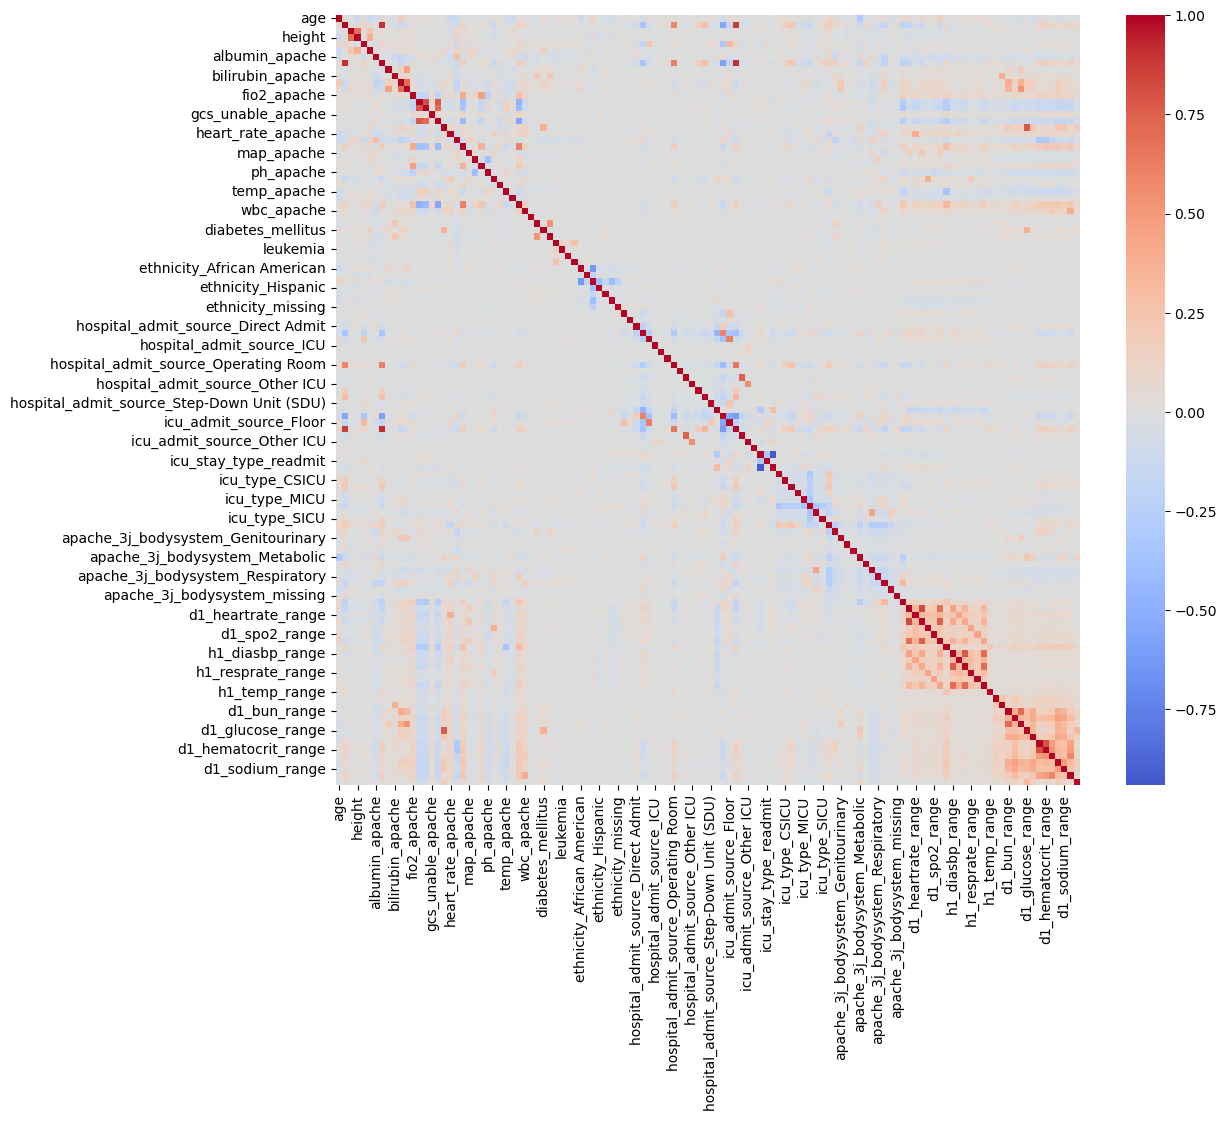

In [20]:
plt.figure(figsize=(12, 10))
sns.heatmap(
    X_train_enc.corr(),
    cmap="coolwarm",
    center=0
)
plt.show()

In [27]:
#odstranime vysoko korelovane atributy, ktore zvnikli pomocou onehotencoder
coded_drop = ['icu_admit_source_Operating Room / Recovery', 'd1_hematocrit_range',
             'd1_diasbp_range']
X_train_enc = X_train_enc.drop(coded_drop, axis = 1)
X_test_enc = X_test_enc.drop(coded_drop, axis = 1)

In [28]:
#prevzorkujeme upravene data
#iba mensinovu triedu na 50%
oversampler = RandomOverSampler(sampling_strategy = 0.5, random_state = 24)
X_train_res05, y_train_res05 = oversampler.fit_resample(X_train_enc, y_train)

#mensinova na 50% a vacsinova na 75%
undersampler = RandomUnderSampler(sampling_strategy = 0.75, random_state = 24)
X_train_res075, y_train_res075 = undersampler.fit_resample(X_train_res05, y_train_res05)

In [29]:
#rozdelime si datasety podla scenarov
#stlpce s apache v nazve
apache_cols = [col for col in X_train_enc.columns if 'apache' in col]
#apache atributy, ktore nemaju apache v nazve
other = ['age', 'pre_icu_los_days','aids', 'cirrhosis', 'diabetes_mellitus',
         'hepatic_failure', 'immunosuppression', 'leukemia', 'lymphoma',
         'solid_tumor_with_metastasis']
#vsetky apache atributy
apache_att = apache_cols + other

train05_apache_only = X_train_res05[apache_att]
train075_apache_only = X_train_res075[apache_att]
train_apache_only = X_train_enc[apache_att]

train05_no_apache = X_train_res05.drop(apache_cols, axis = 1)
train075_no_apache = X_train_res075.drop(apache_cols, axis = 1)
train_no_apache = X_train_enc.drop(apache_cols, axis = 1)

train05_all_data = X_train_res05.drop('apache_post_operative', axis = 1)
train075_all_data = X_train_res075.drop('apache_post_operative', axis = 1)
train_all_data = X_train_enc.drop('apache_post_operative', axis = 1)

Ytrain05 = y_train_res05
Ytrain075 = y_train_res075
Ytrain = y_train

#pre test
test_apache_only = X_test_enc[apache_att]
test_no_apache = X_test_enc.drop(apache_cols, axis = 1)
test_all_data = X_test_enc.drop('apache_post_operative', axis = 1)

In [30]:
train_all_data.to_csv('data/train_all_data.csv', encoding='utf-8', index=False, header=True)
train_no_apache.to_csv('data/train_no_apache.csv', encoding='utf-8', index=False, header=True)
train_apache_only.to_csv('data/train_apache_only.csv', encoding='utf-8', index=False, header=True)
Ytrain.to_csv('data/Ytrain.csv', encoding='utf-8', index=False, header=True)

In [31]:
Ytrain05.to_csv('data/Ytrain05.csv', encoding='utf-8', index=False, header=True)
Ytrain075.to_csv('data/Ytrain075.csv', encoding='utf-8', index=False, header=True)
y_test.to_csv('data/y_test.csv', encoding='utf-8', index=False, header=True)

In [32]:
train05_apache_only.to_csv('data/train05_apache_only.csv', encoding='utf-8', index=False, header=True)
train075_apache_only.to_csv('data/train075_apache_only.csv', encoding='utf-8', index=False, header=True)
test_apache_only.to_csv('data/test_apache_only.csv', encoding='utf-8', index=False, header=True)

In [33]:
train05_no_apache.to_csv('data/train05_no_apache.csv', encoding='utf-8', index=False, header=True)
train075_no_apache.to_csv('data/train075_no_apache.csv', encoding='utf-8', index=False, header=True)
test_no_apache.to_csv('data/test_no_apache.csv', encoding='utf-8', index=False, header=True)

In [34]:
train05_all_data.to_csv('data/train05_all_data.csv', encoding='utf-8', index=False, header=True)
train075_all_data.to_csv('data/train075_all_data.csv', encoding='utf-8', index=False, header=True)
test_all_data.to_csv('data/test_all_data.csv', encoding='utf-8', index=False, header=True)